In [1]:
#import libraries
import numpy as np  
import pandas as pd
#Safe setting for Pandas
pd.set_option('mode.copy_on_write', True)
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
from scipy.stats import fisher_exact
import math 

In [2]:
#import data
matrix = pd.read_csv("./1C/matrix.csv")
matrix.head()

,Participant number,Identity,Voted for,Belonging,Change
0,1,ID-WELSH,Other left-wing party,Strong,NaN
1,2,ID-WELSH-BRITISH,Plaid Cymru,Some,Complex
2,3,ID-WELSH-OTHER,Other left-wing party,Strong,No change
3,4,ID-WELSH-BRITISH,Other left-wing party,Some,Negative
4,5,ID-WELSH,Plaid Cymru,Some,Compex


In [3]:
#drop columns to focus dataset on identity
matrix = matrix.drop(["Participant number", "Belonging", "Change"], axis=1)
matrix.head()

,Identity,Voted for
0,ID-WELSH,Other left-wing party
1,ID-WELSH-BRITISH,Plaid Cymru
2,ID-WELSH-OTHER,Other left-wing party
3,ID-WELSH-BRITISH,Other left-wing party
4,ID-WELSH,Plaid Cymru


In [4]:
#condense categories into plaid cymru and other parties

#map new categories
new_categories_voting = {
    "Other left-wing party": "Other Parties",
    "Right-wing party": "Other Parties",
    "Plaid Cymru": "Plaid Cymru",
}

#replace old categories with new categories
matrix["Voted for"] = matrix["Voted for"].replace(new_categories_voting)

#create table of dataset
fulltable = pd.crosstab(matrix["Identity"], matrix["Voted for"])
fulltable

Voted for,Other Parties,Plaid Cymru
Identity,,
ID-BRITISH,5,1
ID-OTHER,2,1
ID-WELSH,4,10
ID-WELSH-BRITISH,1,4
ID-WELSH-OTHER,4,0


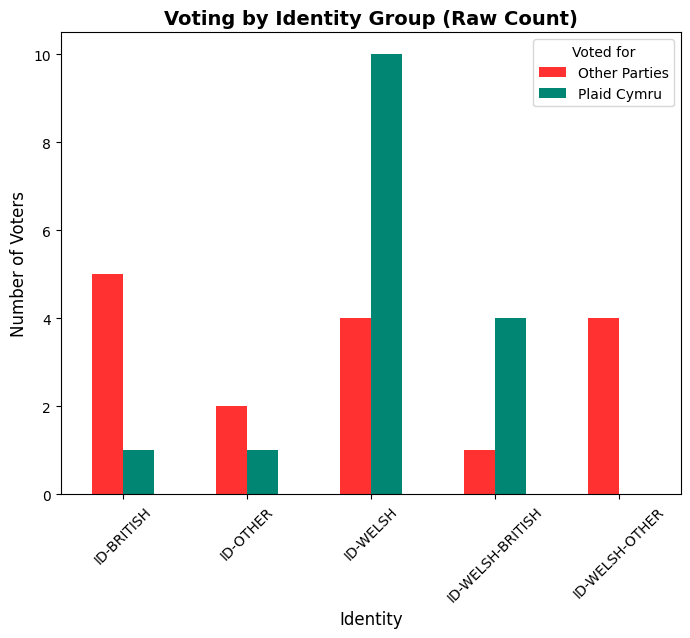

In [5]:
#plot bar graph of counts for full dataset
fullcountgraph = fulltable.plot(kind="bar", figsize=(8, 6), color=["#ff3131", "#008672"])
plt.title("Voting by Identity Group (Raw Count)", fontsize=14, fontweight="bold")
plt.xlabel("Identity", fontsize=12)
plt.ylabel("Number of Voters", fontsize=12)  
plt.xticks(rotation=45)
plt.show()

In [6]:
#create table of percentages
fullpercentages = (
    pd.crosstab(matrix["Identity"], matrix["Voted for"], normalize="index")*100
).astype(int)
fullpercentages

Voted for,Other Parties,Plaid Cymru
Identity,,
ID-BRITISH,83,16
ID-OTHER,66,33
ID-WELSH,28,71
ID-WELSH-BRITISH,20,80
ID-WELSH-OTHER,100,0


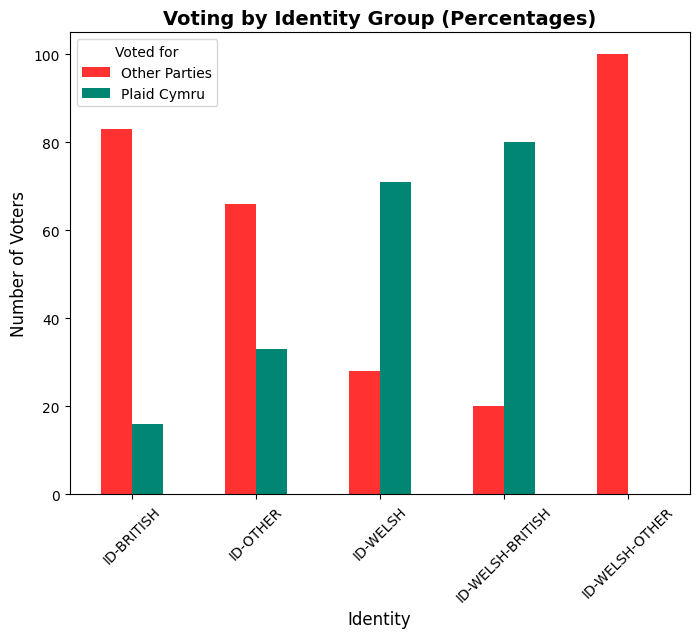

In [7]:
#plot bar graph of percentages for full dataset
fullpercentagesgraph = fullpercentages.plot(kind="bar", figsize=(8, 6), color=["#ff3131", "#008672"])
plt.title("Voting by Identity Group (Percentages)", fontsize=14, fontweight="bold")
plt.xlabel("Identity", fontsize=12)
plt.ylabel("Number of Voters", fontsize=12)  
plt.xticks(rotation=45)
plt.show()

In [8]:
#create new dataframe for welsh identity 
welsh = matrix.copy()

#collapse categories into welsh and non-welsh
#map new categories
new_categories_welsh = {
    "ID-BRITISH": "Non-Welsh",
    "ID-OTHER": "Non-Welsh",
    "ID-WELSH": "Welsh",
    "ID-WELSH-BRITISH": "Welsh",
    "ID-WELSH-OTHER": "Welsh",
}

#create table with new categories for welsh identity
welshtable = pd.crosstab(
    welsh["Identity"].replace(new_categories_welsh), welsh["Voted for"]
)

#create table of percentages for welsh identity
welshpercentages = (pd.crosstab(
        welsh["Identity"].replace(new_categories_welsh), welsh["Voted for"], normalize="index")* 100
).round(2)

#reorder tables for ease of focus and for later statistical testing
#reorder rows
welsh_row_order = ["Welsh", "Non-Welsh"]  
welshtable = welshtable.reindex(index=welsh_row_order)
welshpercentages = welshpercentages.reindex(index=welsh_row_order)
#reorder columns
welsh_column_order = ["Plaid Cymru", "Other Parties"]
welshtable = welshtable.reindex(columns=welsh_column_order)
welshpercentages = welshpercentages.reindex(columns=welsh_column_order)
#check to see these have been correctly ordered
print(welshtable)
print(welshpercentages)

Voted for  Plaid Cymru  Other Parties
Identity                             
Welsh               14              9
Non-Welsh            2              7
Voted for  Plaid Cymru  Other Parties
Identity                             
Welsh            60.87          39.13
Non-Welsh        22.22          77.78


In [9]:
#create new dataframe for other identity 
other = matrix.copy()
#collapse categories into non-uk identity and no non-uk identity
#map new categories
new_categories_other = {
    "ID-BRITISH": "No Presence of Non-UK Identity",
    "ID-OTHER": "Presence of Non-UK Identity",
    "ID-WELSH": "No Presence of Non-UK Identity",
    "ID-WELSH-BRITISH": "No Presence of Non-UK Identity",
    "ID-WELSH-OTHER": "Presence of Non-UK Identity",
}

#create table with new categories for other identity
othertable = pd.crosstab(
    other["Identity"].replace(new_categories_other), other["Voted for"]
)

#create table of percentages for other identity
otherpercentages = (pd.crosstab(
        other["Identity"].replace(new_categories_other), other["Voted for"], normalize="index")* 100
).round(2)

#reorder tables for ease of focus and for later statistical testing
#reorder rows
other_row_order = ["Presence of Non-UK Identity", "No Presence of Non-UK Identity"]  
othertable = othertable.reindex(index=other_row_order)
otherpercentages = otherpercentages.reindex(index=other_row_order)
#reorder columns
othertable = othertable.reindex(columns=welsh_column_order)
otherpercentages = otherpercentages.reindex(columns=welsh_column_order)
#check to see these have been correctly ordered
print(othertable)
print(otherpercentages)

Voted for                       Plaid Cymru  Other Parties
Identity                                                  
Presence of Non-UK Identity               1              6
No Presence of Non-UK Identity           15             10
Voted for                       Plaid Cymru  Other Parties
Identity                                                  
Presence of Non-UK Identity           14.29          85.71
No Presence of Non-UK Identity        60.00          40.00


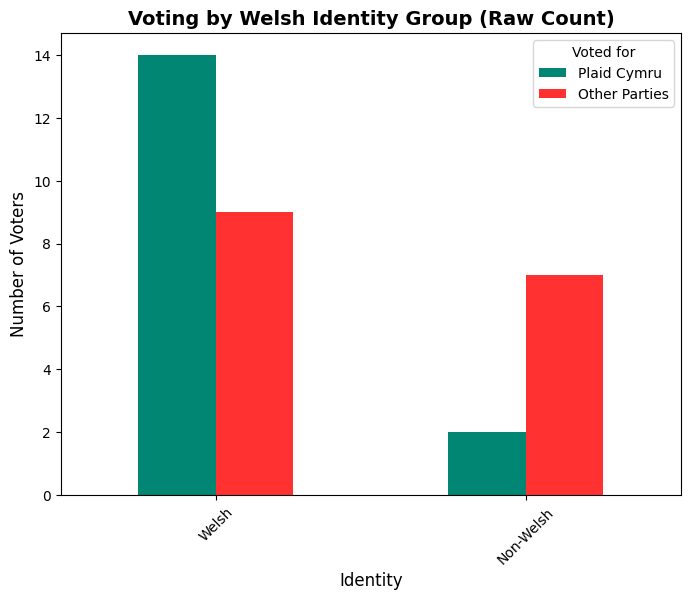

In [10]:
#plot bar graph of raw count for welsh dataset
welshgraphcount = welshtable.plot(kind="bar", figsize=(8, 6), color=["#008672", "#ff3131"])
plt.title("Voting by Welsh Identity Group (Raw Count)", fontsize=14, fontweight="bold")
plt.xlabel("Identity", fontsize=12)
plt.ylabel("Number of Voters", fontsize=12)  
plt.xticks(rotation=45)
plt.show()

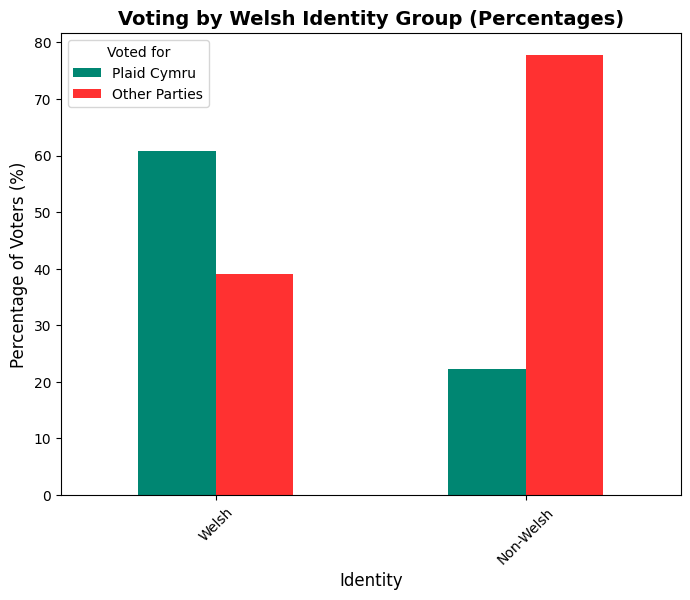

In [11]:
#plot bar graph of percentages for welsh dataset
welshgraphpercentages = welshpercentages.plot(kind="bar", figsize=(8, 6), color=["#008672", "#ff3131"])
plt.title("Voting by Welsh Identity Group (Percentages)", fontsize=14, fontweight="bold")
plt.xlabel("Identity", fontsize=12)
plt.ylabel("Percentage of Voters (%)", fontsize=12)  
plt.xticks(rotation=45)
plt.show()

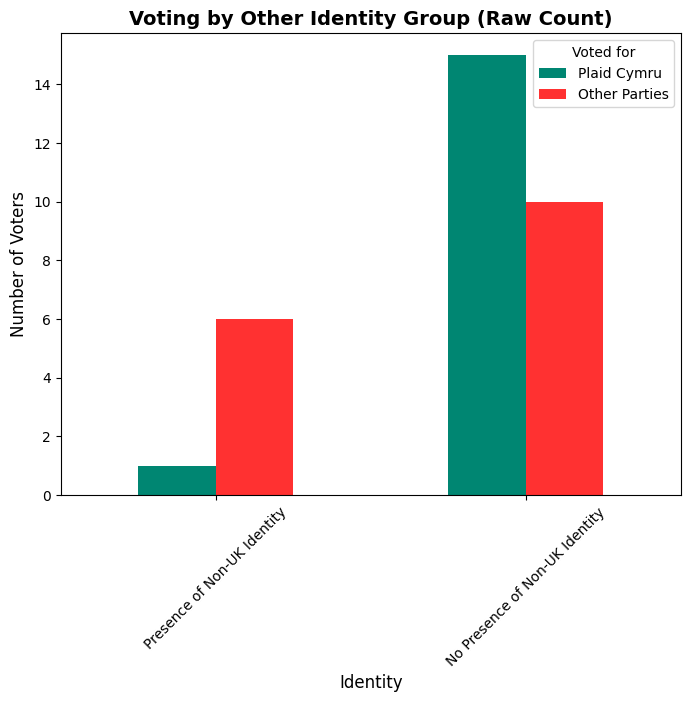

In [12]:
#plot bar graph of raw count for other dataset
othergraphcount = othertable.plot(kind="bar", figsize=(8, 6), color=["#008672", "#ff3131"])
plt.title("Voting by Other Identity Group (Raw Count)", fontsize=14, fontweight="bold")
plt.xlabel("Identity", fontsize=12)
plt.ylabel("Number of Voters", fontsize=12)  
plt.xticks(rotation=45)
plt.show()

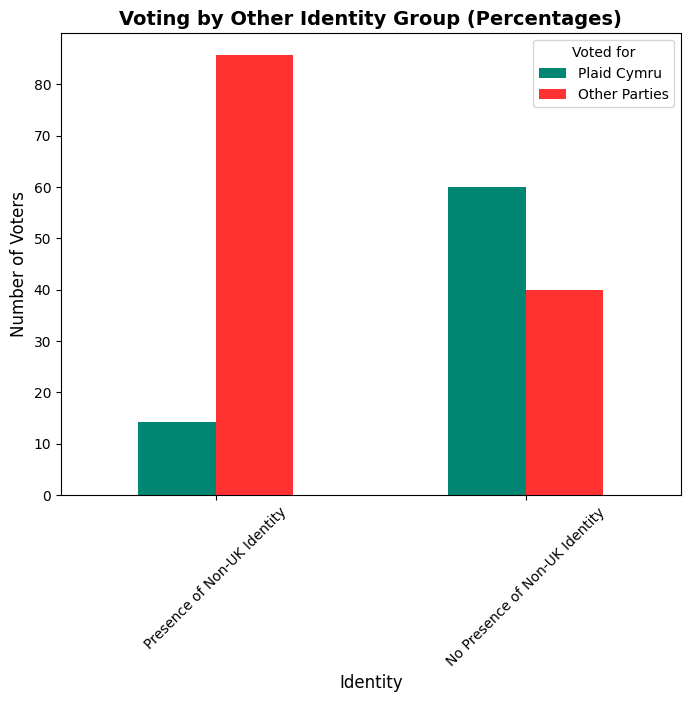

In [13]:
#plot bar graph of percentages for other dataset
othergraphpercentages = otherpercentages.plot(kind="bar", figsize=(8, 6), color=["#008672", "#ff3131"])
plt.title("Voting by Other Identity Group (Percentages)", fontsize=14, fontweight="bold")
plt.xlabel("Identity", fontsize=12)
plt.ylabel("Number of Voters", fontsize=12)  
plt.xticks(rotation=45)
plt.show()

In [14]:
#create crosstab showing both raw counts and percentages for welsh identity
welshfulltable = welshpercentages.astype(str) + "% (n=" + welshtable.astype(str) + ")"
welshfulltable
#check
welshfulltable

Voted for,Plaid Cymru,Other Parties
Identity,,
Welsh,60.87% (n=14),39.13% (n=9)
Non-Welsh,22.22% (n=2),77.78% (n=7)


In [15]:
#create crosstab showing both raw counts and percentages for other identity
otherfulltable = otherpercentages.astype(str) + "% (n=" + othertable.astype(str) + ")"
#check
otherfulltable

Voted for,Plaid Cymru,Other Parties
Identity,,
Presence of Non-UK Identity,14.29% (n=1),85.71% (n=6)
No Presence of Non-UK Identity,60.0% (n=15),40.0% (n=10)


In [16]:
#new_order = ["Plaid Cymru", "Other Parties"]
#welshtable = welshtable.reindex(columns=new_order)
#welshtable

In [17]:
# performing fishers exact test on welsh data
welsh_odds, welsh_pvalue = fisher_exact(welshtable, alternative="greater")
#print p-value and odds ratio
print (f"odds ratio is: {welsh_odds}")
print (f"p_value is: {welsh_pvalue}")

odds ratio is: 5.444444444444445
p_value is: 0.05669262143121986


In [18]:
#print welshtable to input data for phi coefficient
print (welshtable)

Voted for  Plaid Cymru  Other Parties
Identity                             
Welsh               14              9
Non-Welsh            2              7


In [19]:
#calculate phi coefficient
welsh_numerator = (14 * 7)-(9 * 2)
welsh_denominator = ((23)*(9)*(16)*(16))**(0.5)
welsh_phi = welsh_numerator/welsh_denominator
#print phi coefficient
print (f"phi coefficient is: {welsh_phi}")

phi coefficient is: 0.34752402342845795


In [20]:
# performing fishers exact test on other data
other_odds, other_pvalue = fisher_exact(othertable, alternative="less")
print (f"odd ratio is: {other_odds}")
print (f"p_value is: {other_pvalue}")

odd ratio is: 0.1111111111111111
p_value is: 0.04146582622667161


In [21]:
#print othertable to input data for phi coefficient
print (othertable)

Voted for                       Plaid Cymru  Other Parties
Identity                                                  
Presence of Non-UK Identity               1              6
No Presence of Non-UK Identity           15             10


In [22]:
#calculate phi coefficient
other_numerator = (6 * 15)-(1 * 10)
other_denominator = ((7)*(25)*(16)*(16))**(0.5)
other_phi = other_numerator/other_denominator
#print phi coefficient
print (f"phi coefficient is: {other_phi}")

phi coefficient is: 0.37796447300922725


In [23]:
#import data to create new dataset for change
change_matrix = pd.read_csv("./1C/matrix.csv")
change_matrix.head()

,Participant number,Identity,Voted for,Belonging,Change
0,1,ID-WELSH,Other left-wing party,Strong,NaN
1,2,ID-WELSH-BRITISH,Plaid Cymru,Some,Complex
2,3,ID-WELSH-OTHER,Other left-wing party,Strong,No change
3,4,ID-WELSH-BRITISH,Other left-wing party,Some,Negative
4,5,ID-WELSH,Plaid Cymru,Some,Compex


In [24]:
#drop columns to focus dataset on change
change_matrix = change_matrix.drop(["Participant number", "Belonging", "Identity"], axis=1)
change_matrix.head()

,Voted for,Change
0,Other left-wing party,NaN
1,Plaid Cymru,Complex
2,Other left-wing party,No change
3,Other left-wing party,Negative
4,Plaid Cymru,Compex


In [25]:
#remove typo in dataset
remove_typo = {"Compex": "Complex"}
change_matrix["Change"] = change_matrix["Change"].replace(remove_typo)
#clean data to remove nan
change_matrix = change_matrix.dropna(subset=["Change"])

In [26]:
#collapse into plaid and other parties
change_matrix["Voted for"] = change_matrix["Voted for"].replace(new_categories_voting)
#create table of dataset
change_table = pd.crosstab(change_matrix["Change"], change_matrix["Voted for"])
#reorder table
change_table = change_table.reindex(columns=welsh_column_order)
change_table

Voted for,Plaid Cymru,Other Parties
Change,,
Complex,10,2
Negative,1,7
No change,2,2
Positive,2,2


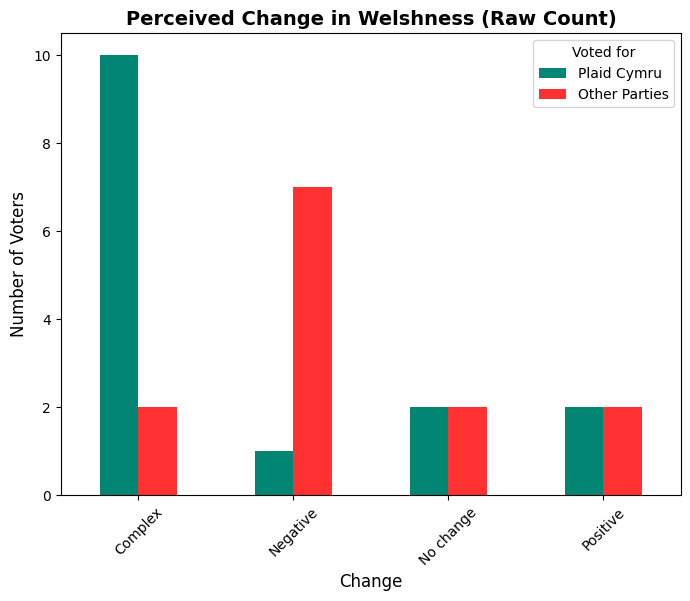

In [27]:
#plot bar graph of full change data
change_graph = change_table.plot(kind="bar", figsize=(8, 6), color=["#008672", "#ff3131"])
plt.title("Perceived Change in Welshness (Raw Count)", fontsize=14, fontweight="bold")
plt.xlabel("Change", fontsize=12)
plt.ylabel("Number of Voters", fontsize=12)  
plt.xticks(rotation=45)
plt.show()

In [28]:
#collapse categories
new_categories_change = {
    "Complex": "Positive Change",
    "Positive": "Positive Change",
    "Negative": "No Positive Change",
    "No change": "No Positive Change",
}

#create table for change
change_table = pd.crosstab(
    change_matrix["Change"].replace(new_categories_change), change_matrix["Voted for"]
)

#create table of percentages for change
change_percentages = (pd.crosstab(
        change_matrix["Change"].replace(new_categories_change), change_matrix["Voted for"], normalize="index")* 100
).round(2)

#reorder columns
change_table = change_table.reindex(columns=welsh_column_order)
change_percentages = change_percentages.reindex(columns=welsh_column_order)
#reorder rows
change_row_order = ["Positive Change", "No Positive Change"]  
change_table = change_table.reindex(index=change_row_order)
change_percentages = change_percentages.reindex(index=change_row_order)
#check
print(change_table)
print(change_percentages)

Voted for           Plaid Cymru  Other Parties
Change                                        
Positive Change              12              4
No Positive Change            3              9
Voted for           Plaid Cymru  Other Parties
Change                                        
Positive Change            75.0           25.0
No Positive Change         25.0           75.0


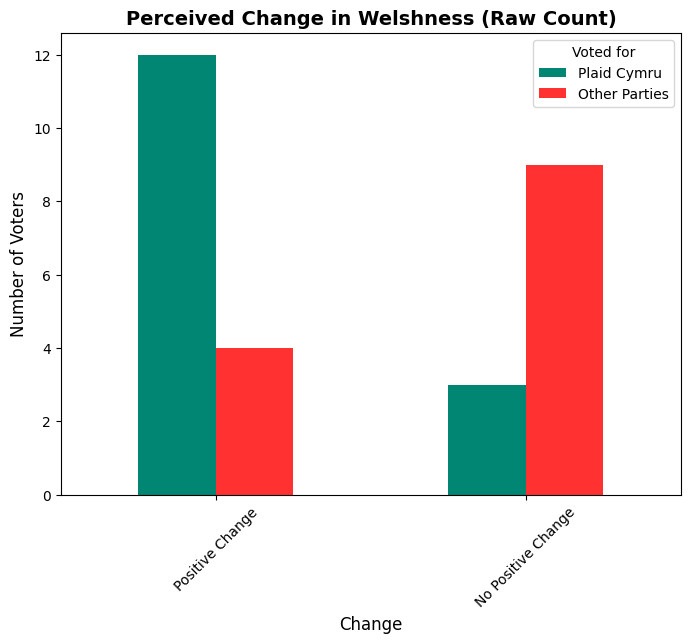

In [29]:
#plot bar graph of change raw count
change_graph_count = change_table.plot(kind="bar", figsize=(8, 6), color=["#008672", "#ff3131"])
plt.title("Perceived Change in Welshness (Raw Count)", fontsize=14, fontweight="bold")
plt.xlabel("Change", fontsize=12)
plt.ylabel("Number of Voters", fontsize=12)  
plt.xticks(rotation=45)
plt.show()

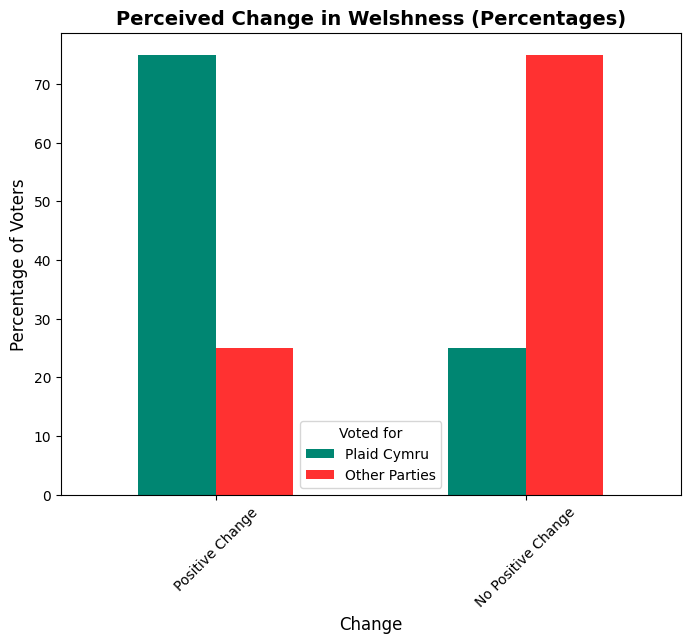

In [30]:
#plot bar graph of change percentages
change_graph_percentages = change_percentages.plot(kind="bar", figsize=(8, 6), color=["#008672", "#ff3131"])
plt.title("Perceived Change in Welshness (Percentages)", fontsize=14, fontweight="bold")
plt.xlabel("Change", fontsize=12)
plt.ylabel("Percentage of Voters", fontsize=12)  
plt.xticks(rotation=45)
plt.show()

In [31]:
#create crosstab showing both raw counts and percentages for other identity
change_full_table = change_percentages.astype(str) + "% (n=" + change_table.astype(str) + ")"
#check
change_full_table

Voted for,Plaid Cymru,Other Parties
Change,,
Positive Change,75.0% (n=12),25.0% (n=4)
No Positive Change,25.0% (n=3),75.0% (n=9)


In [32]:
#perform fishers exact test on change data
change_odds, change_pvalue = fisher_exact(change_table, alternative="greater")
#print results
print (f"odd ratio is: {change_odds}")
print (f"p_value is: {change_pvalue}")

odd ratio is: 9.0
p_value is: 0.0117198366760892


In [33]:
#print table
print (change_table)

Voted for           Plaid Cymru  Other Parties
Change                                        
Positive Change              12              4
No Positive Change            3              9


In [34]:
#calculate phi coefficient
change_numerator = (12 * 9)-(4 * 3)
change_denominator = ((16)*(12)*(15)*(13))**(0.5)
change_phi = change_numerator/change_denominator
#print phi coefficient
print (f"phi coefficient is: {change_phi}")

phi coefficient is: 0.49613893835683387


In [35]:
#import data for new belonging dataset
belonging_matrix = pd.read_csv("./1C/matrix.csv")
belonging_matrix.head()

,Participant number,Identity,Voted for,Belonging,Change
0,1,ID-WELSH,Other left-wing party,Strong,NaN
1,2,ID-WELSH-BRITISH,Plaid Cymru,Some,Complex
2,3,ID-WELSH-OTHER,Other left-wing party,Strong,No change
3,4,ID-WELSH-BRITISH,Other left-wing party,Some,Negative
4,5,ID-WELSH,Plaid Cymru,Some,Compex


In [36]:
#drop columns to focus dataset on belonging
belonging_matrix = belonging_matrix.drop(["Participant number", "Change", "Identity"], axis=1)
belonging_matrix.head()

,Voted for,Belonging
0,Other left-wing party,Strong
1,Plaid Cymru,Some
2,Other left-wing party,Strong
3,Other left-wing party,Some
4,Plaid Cymru,Some


In [37]:
#collapse categories into plaid and not plaid
belonging_matrix["Voted for"] = belonging_matrix["Voted for"].replace(new_categories_voting)
#create table
belonging_table = pd.crosstab(belonging_matrix["Belonging"], belonging_matrix["Voted for"])
#reorder
belonging_table = belonging_table.reindex(columns=welsh_column_order)
#check
belonging_table

Voted for,Plaid Cymru,Other Parties
Belonging,,
No,1,1
Some,4,1
Some,1,1
Strong,10,12
Strong,0,1


In [38]:
#collapse categories into high and low belonging
new_categories_belonging = {
    "Some": "Low",
    "Some ": "Low",
    "No": "Low",
    "Strong": "High",
    "Strong ": "High",
}
#create table for belonging
belonging_table = pd.crosstab(
    belonging_matrix["Belonging"].replace(new_categories_belonging), belonging_matrix["Voted for"]
)
#reorder
belonging_table = belonging_table.reindex(columns=welsh_column_order)
#check
print(belonging_table)

Voted for  Plaid Cymru  Other Parties
Belonging                            
High                10             13
Low                  6              3


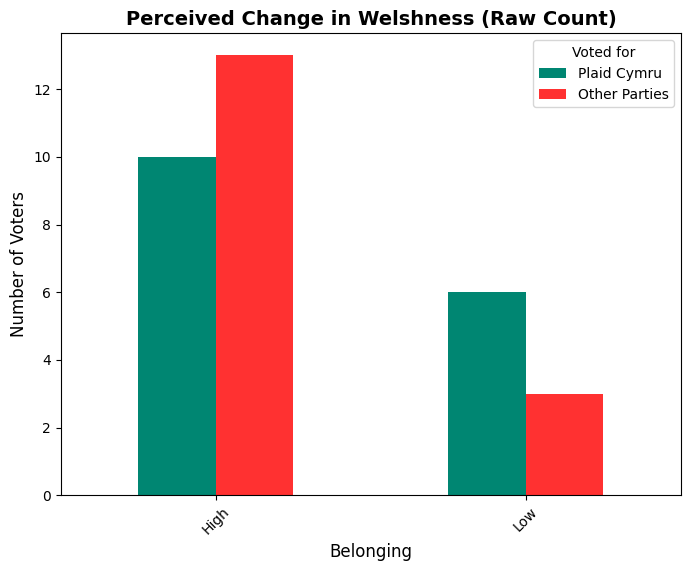

In [39]:
#plot bar graph of belonging raw count
belonging_graph_count = belonging_table.plot(kind="bar", figsize=(8, 6), color=["#008672", "#ff3131"])
plt.title("Perceived Change in Welshness (Raw Count)", fontsize=14, fontweight="bold")
plt.xlabel("Belonging", fontsize=12)
plt.ylabel("Number of Voters", fontsize=12)  
plt.xticks(rotation=45)
plt.show()

In [40]:
#perform fishers exact test on belonging data
bel_odds, bel_pvalue = fisher_exact(belonging_table, alternative="less")
#print results
print (f"odds ratio is: {bel_odds}")
print (f"p_value is: {bel_pvalue}")

odds ratio is: 0.38461538461538464
p_value is: 0.2165739710789766


In [41]:
#print table
print (belonging_table)

Voted for  Plaid Cymru  Other Parties
Belonging                            
High                10             13
Low                  6              3


In [42]:
#calculate phi coefficient
bel_numerator = (16 * 3)-(13 * 6)
bel_denominator = ((23)*(9)*(16)*(16))**(0.5)
bel_phi = bel_numerator/bel_denominator
print (f"phi coefficient is: {bel_phi}")

phi coefficient is: -0.13032150878567172
